# Compare Residue Distances (v2)

This notebook is a streamlined replacement for `Compare_Residue_Distances.ipynb`.

Key differences vs v1:
- No `set_manual` branching.
- One **config JSON** per analysis variable stored *alongside* cached per-simulation CSVs.
- Intermediate per-simulation CSVs are treated as a **cache** (distance calculations are only performed when CSVs are missing, unless you force recompute).

Expected inputs:
- A trajectory **index CSV** with at least: `sim_number`, `sim_description`, `psf_path`, `dcd_path`, `time_factor`.

Outputs (written to `out_dir`):
- `{short_var_name}_config.json`
- `{sim}_{short_var_name}.csv` (cached distances)
- `SUMMARY_{short_var_name}.csv` (summary stats)
- Plots (optional, if you run plotting sections)


In [1]:
# Parameters (edit this cell)

import os
import sys
from pathlib import Path

# Default paths strategy (no GUI):
# - Prefer explicit environment variables (good for GitHub + HPC)
# - Otherwise, fall back to your local manuscript defaults *if they exist*
# - Otherwise, fall back to repo-relative paths

# Try to infer repo root (expects a `src/` folder at the repo root).
_cwd = Path.cwd().resolve()
if (_cwd / "src").is_dir():
    REPO_ROOT = _cwd
elif (_cwd.parent / "src").is_dir():
    REPO_ROOT = _cwd.parent
else:
    REPO_ROOT = Path(os.getenv("MD_REPO_ROOT", _cwd)).resolve()

SRC_DIR = REPO_ROOT / "src"
if SRC_DIR.is_dir() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# 1) Index CSV
if "MD_INDEX_CSV" in os.environ:
    INDEX_CSV = Path(os.environ["MD_INDEX_CSV"]).expanduser().resolve()
else:
    _candidates = [
        Path(r"D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/FtsW Manuscript/Anton_SimulationIndex20260413.csv"),
        REPO_ROOT / "data" / "trajectory_index.csv",
    ]
    INDEX_CSV = next((p.resolve() for p in _candidates if p.exists()), _candidates[-1].resolve())

# 2) Output root
# If you point OUT_ROOT at your existing manuscript folder, the notebook will *reuse* cached CSVs.
# The default below uses the directory containing the index CSV (common in your current layout).
OUT_ROOT = Path(os.getenv("MD_OUT_ROOT", INDEX_CSV.parent)).expanduser().resolve()

# Curated paper sim lists
# Use env var flag:
# - MD_PAPER_SIMSET=revisions (default)
# - MD_PAPER_SIMSET=main
PAPER_SIMSET = os.getenv("MD_PAPER_SIMSET", "revisions").strip().lower()
CURATED_DIR = (REPO_ROOT / "notebooks" / "curated").resolve()

if PAPER_SIMSET == "main":
    PAPER_LIST_FILE = (CURATED_DIR / "paper_main.txt").resolve()
    PRESET_NAME = "paper_main"
else:
    PAPER_LIST_FILE = (CURATED_DIR / "paper_revisions.txt").resolve()
    PRESET_NAME = "paper_revisions"

# Simulations to load
# - Set SIM_LIST explicitly to a list like ['14', '14b', 'A']
# - Or leave SIM_LIST=None to use the curated paper list above
SIM_LIST = None

# Cache behavior
FORCE_RECOMPUTE = False

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"SRC_DIR:   {SRC_DIR}")
print(f"INDEX_CSV: {INDEX_CSV}")
print(f"OUT_ROOT:  {OUT_ROOT}")
print(f"PRESET_NAME: {PRESET_NAME}")
print(f"PAPER_LIST_FILE: {PAPER_LIST_FILE}")
print(f"FORCE_RECOMPUTE: {FORCE_RECOMPUTE}")

REPO_ROOT: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\Code_Resources\FtsW-dynamics
SRC_DIR:   D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\Code_Resources\FtsW-dynamics\src
INDEX_CSV: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\Anton_SimulationIndex20260413.csv
OUT_ROOT:  D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript
PRESET_NAME: paper_revisions
PAPER_LIST_FILE: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\Code_Resources\FtsW-dynamics\notebooks\curated\paper_revisions.txt
FORCE_RECOMPUTE: False


In [2]:
# Imports (v2)

import numpy as np
import pandas as pd

# v2: use extracted, non-GUI helpers (not MYT_functions)
from traj_utils import validate_traj_index, read_trajectories
from plotting import plot_dist_time_trace_hist

from distance_analysis import (
    DistanceAnalysisConfig,
    PlotStyle,
    compute_distance_csvs,
    load_or_create_config,
    make_summary_table,
)

# Canonical style index (labels/colors)
STYLE_CSV = (REPO_ROOT / "notebooks" / "curated" / "sim_style.csv").resolve()

def _load_label_map(style_csv):
    df = pd.read_csv(style_csv)
    out = {}
    for _, r in df.iterrows():
        sim = str(r.get("sim_number", "")).strip()
        if not sim:
            continue
        label_explicit = str(r.get("label_explicit", "")).strip().replace("\\\\", "\\")
        label_default = str(r.get("label_default", "")).strip().replace("\\\\", "\\")
        label = label_explicit if label_explicit else label_default
        if label:
            out[sim] = label
    return out

LABEL_MAP = _load_label_map(STYLE_CSV)
print(f"STYLE_CSV: {STYLE_CSV}")
print(f"Loaded labels for sims: {len(LABEL_MAP)}")


STYLE_CSV: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\Code_Resources\FtsW-dynamics\notebooks\curated\sim_style.csv
Loaded labels for sims: 23


In [3]:
# Load index CSV, determine sims, then load trajectories (efficient)

from curated_lists import read_curated_sim_list

valid_df = validate_traj_index(str(INDEX_CSV))

all_sims = list(valid_df["sim_number"].astype(str).values)

if SIM_LIST is None:
    curated_sims = read_curated_sim_list(PAPER_LIST_FILE, required=True)
    sim_list = [s for s in curated_sims if s in set(all_sims)]
else:
    sim_list = [str(s) for s in SIM_LIST]

print(f"Available sims in index: {len(all_sims)}")
print(f"Selected sims: {sim_list}")

u_list, label_list, tf_list = read_trajectories(valid_df, sim_list)


Missing system file (PSF): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/36_kpn_S1S3_Mg_310K/p000-004_p088-92_clean.pdb
Missing trajectory file (DCD): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/36_kpn_S1S3_Mg_310K/p000-004_p088-92_clean.dcd
Missing system file (PSF): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/37_ccr_S1S3_Mg_310K/p000-004_p096-100_clean.pdb
Missing trajectory file (DCD): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/37_ccr_S1S3_Mg_310K/p000-004_p096-100_clean.dcd
D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\Anton_SimulationIndex20260413.csv
Available sims in index: 32
Selected sims: ['8', '14', '14b', '15', '15b', '53', '54', '58', '42', '43', '48', '49']
reading: 8
8: 4202 frames, 1008.48 ns
reading: 14
14: 4200 frames, 1008.0 

In [4]:
# Define or load analysis config
#
# Key idea: `resolve_out_dir` will reuse an existing cache folder even if its
# name doesn't match `short_var_name`, by scanning OUT_ROOT and its immediate
# subfolders for:
# - `{short_var_name}_config.json`
# - legacy metadata JSON containing `short_var_name`
# - cached CSVs like `*_{short_var_name}.csv`

from distance_analysis import resolve_out_dir

short_var_name = "FtsW_L198-L236"

# Optional override if you want to force a specific legacy folder.
OUT_DIR_OVERRIDE = None
# Example:
# OUT_DIR_OVERRIDE = r"D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/FtsW Manuscript/FtsW_K370_L198_Ca_dist"

out_dir = Path(
    resolve_out_dir(
        out_root=str(OUT_ROOT),
        short_var_name=short_var_name,
        out_dir_override=OUT_DIR_OVERRIDE,
        prefer_existing=True,
    )
).resolve()

print(f"Resolved out_dir: {out_dir}")

default_cfg = DistanceAnalysisConfig(
    var_name="FtsW L198 - L236",
    short_var_name=short_var_name,
    res1="(segid PROD PAG1 PAU1) and resid 198 and (name CA)",
    res2="(segid PROD PAG1 PAU1) and resid 236 and (name CA)",
    dist_type="any",
    plot_list=sim_list,
    out_dir=str(out_dir),
    x_cutoff=13.0,
    plot_style=PlotStyle(
        share_lim=True,
        x_min_shared=0.0,
        x_max_shared=15.0,
        max_hist=0.4,
        scale=2.6,
        var_name_plot=None,
    ),
)

cfg, cfg_path = load_or_create_config(
    out_dir=str(out_dir),
    short_var_name=short_var_name,
    default=default_cfg,
    overwrite=True,
)

print(f"Config path: {cfg_path}")
print(f"Output dir:  {cfg.out_dir}")
print(f"Sims:        {len(cfg.plot_list)}")


Resolved out_dir: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_L198_L236_Ca_dist
Config path: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_L198_L236_Ca_dist\FtsW_L198-L236_config.json
Output dir:  D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_L198_L236_Ca_dist
Sims:        12


In [5]:
# Compute (or reuse cached) per-simulation CSVs

data_dict = compute_distance_csvs(
    cfg=cfg,
    sim_list=sim_list,
    u_list=u_list,
    tf_list=tf_list,
    force_recompute=FORCE_RECOMPUTE,
)

print(f"Cached CSVs available: {len(data_dict)}")
list(data_dict.items())[:3]  # preview


Cached CSVs available: 12


[('8',
  'D:\\Xiao Lab Dropbox\\Lab Members\\Yehya_Nico\\Projects\\MDfolder\\FtsW Manuscript\\FtsW_L198_L236_Ca_dist\\8_FtsW_L198-L236.csv'),
 ('14',
  'D:\\Xiao Lab Dropbox\\Lab Members\\Yehya_Nico\\Projects\\MDfolder\\FtsW Manuscript\\FtsW_L198_L236_Ca_dist\\14_FtsW_L198-L236.csv'),
 ('14b',
  'D:\\Xiao Lab Dropbox\\Lab Members\\Yehya_Nico\\Projects\\MDfolder\\FtsW Manuscript\\FtsW_L198_L236_Ca_dist\\14b_FtsW_L198-L236.csv')]

In [6]:
# Summary table (fast; reads CSV cache)

summary_csv = Path(cfg.out_dir) / f"SUMMARY_{cfg.short_var_name}.csv"
summary_df = make_summary_table(data_dict, str(summary_csv), x_cutoff=cfg.x_cutoff)
summary_df.sort_values("sim_id").head(10)


,sim_id,csv_path,n_points,min,mean,std,stderr,max,fraction_below_cutoff,error
1,14,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,4200,11.909278,13.501594,0.471912,0.007282,15.378736,0.133810,
2,14b,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,4200,10.022283,12.497367,1.070703,0.016521,17.100293,0.762381,
3,15,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,4200,8.920702,12.255304,1.122699,0.017324,16.652591,0.776905,
4,15b,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,4200,9.619194,12.073604,1.086242,0.016761,16.436472,0.791429,
8,42,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,3310,7.219432,8.236456,0.311533,0.005415,9.566569,1.000000,
9,43,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,3310,7.100780,8.197547,0.384910,0.006690,10.361148,1.000000,
10,48,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,625,9.803009,15.347597,2.137823,0.085513,21.367150,0.134400,
11,49,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,335,19.627711,20.900721,0.392782,0.021460,22.353501,0.000000,
5,53,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,840,7.830159,12.123863,1.453475,0.050150,17.016894,0.776190,
6,54,D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Pro...,830,8.890764,10.291224,0.556069,0.019301,12.913775,1.000000,


8: Min = 8.5 Å | Frame 1302/4202 | Time 312.24 ns
8: Mean = 11.5 Å | Fraction < 13.0 Å = 89.79%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_L198_L236_Ca_dist\8_FtsW_L198-L236.png


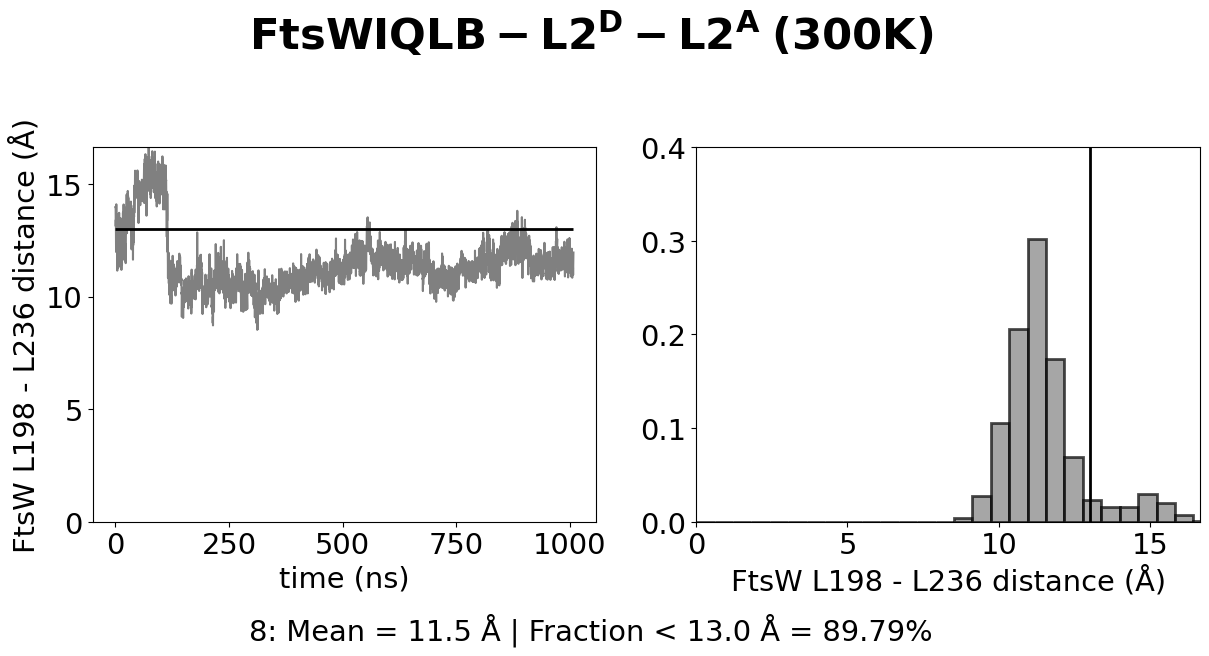

14: Min = 11.9 Å | Frame 128/4200 | Time 30.48 ns
14: Mean = 13.5 Å | Fraction < 13.0 Å = 13.38%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_L198_L236_Ca_dist\14_FtsW_L198-L236.png


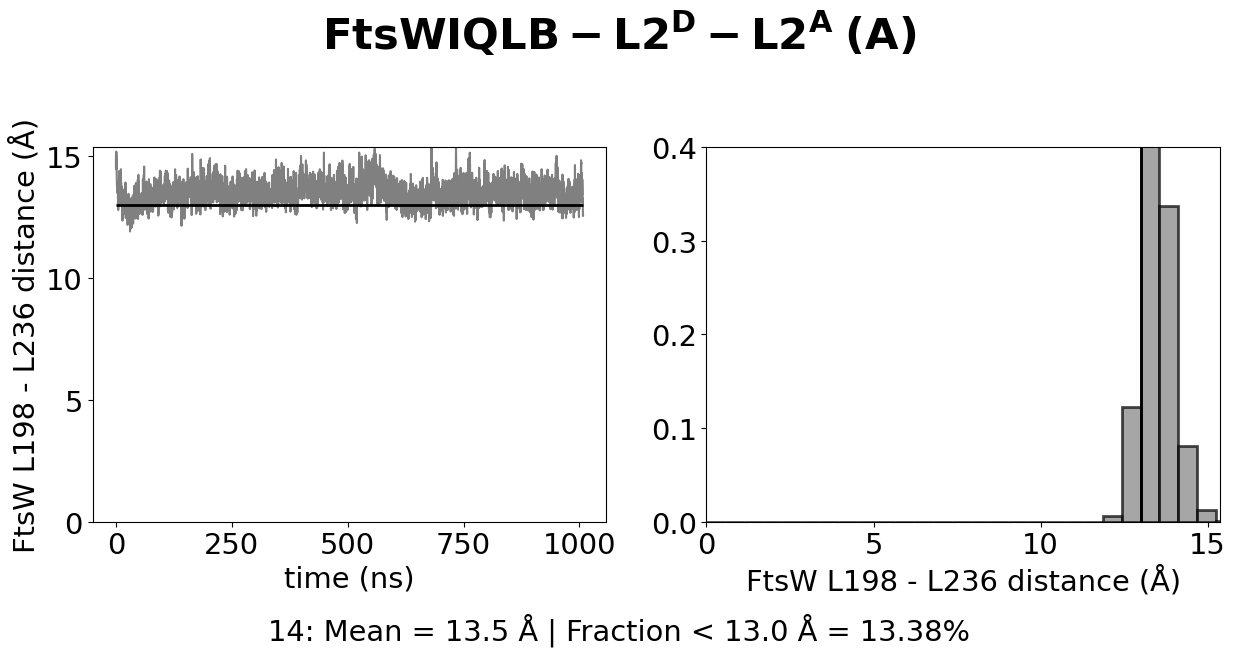

14b: Min = 10.0 Å | Frame 4160/4200 | Time 998.16 ns
14b: Mean = 12.5 Å | Fraction < 13.0 Å = 76.24%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_L198_L236_Ca_dist\14b_FtsW_L198-L236.png


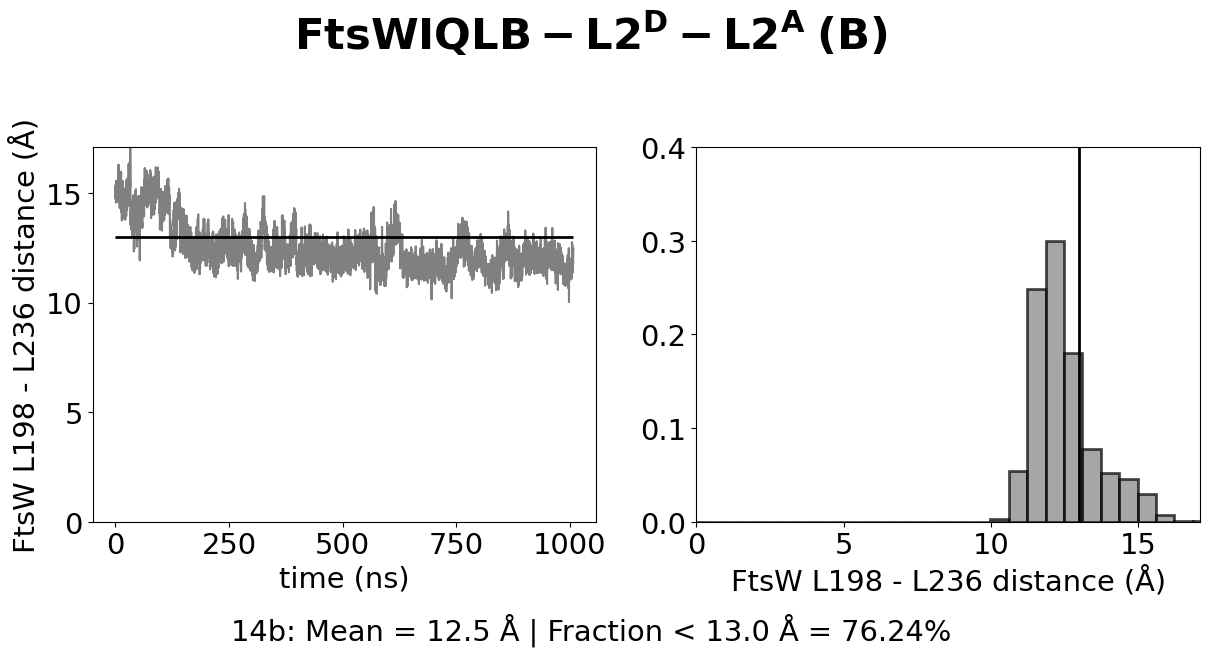

15: Min = 8.9 Å | Frame 3374/4200 | Time 809.52 ns
15: Mean = 12.3 Å | Fraction < 13.0 Å = 77.69%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_L198_L236_Ca_dist\15_FtsW_L198-L236.png


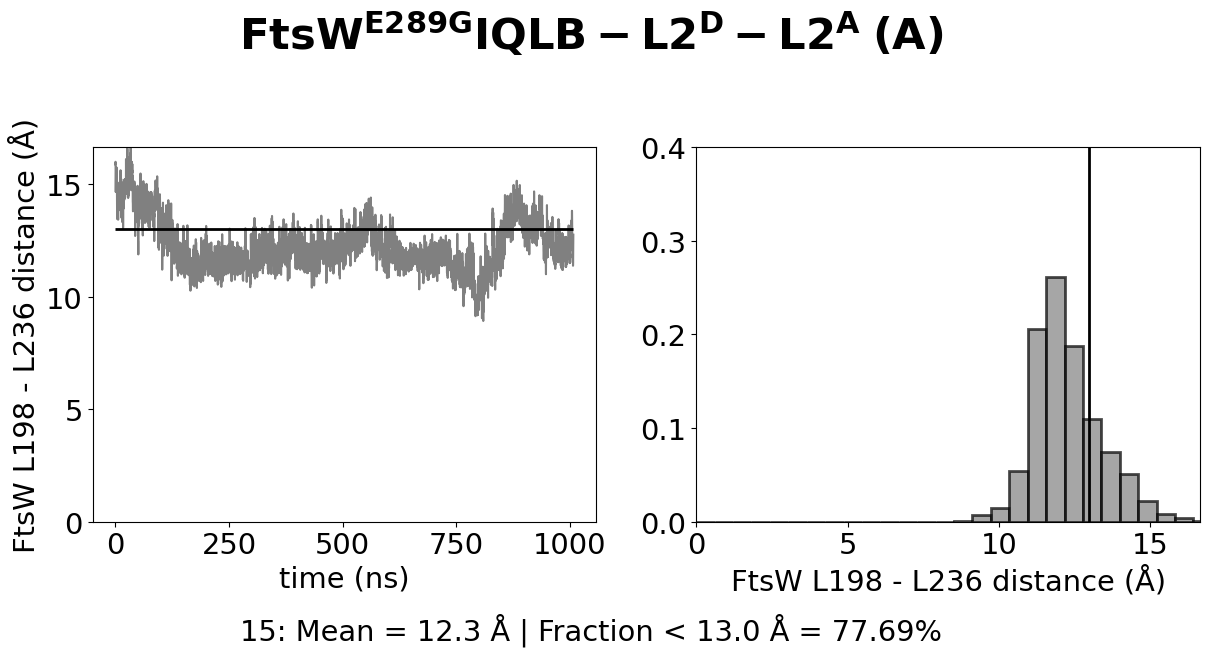

15b: Min = 9.6 Å | Frame 4094/4200 | Time 982.32 ns
15b: Mean = 12.1 Å | Fraction < 13.0 Å = 79.14%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_L198_L236_Ca_dist\15b_FtsW_L198-L236.png


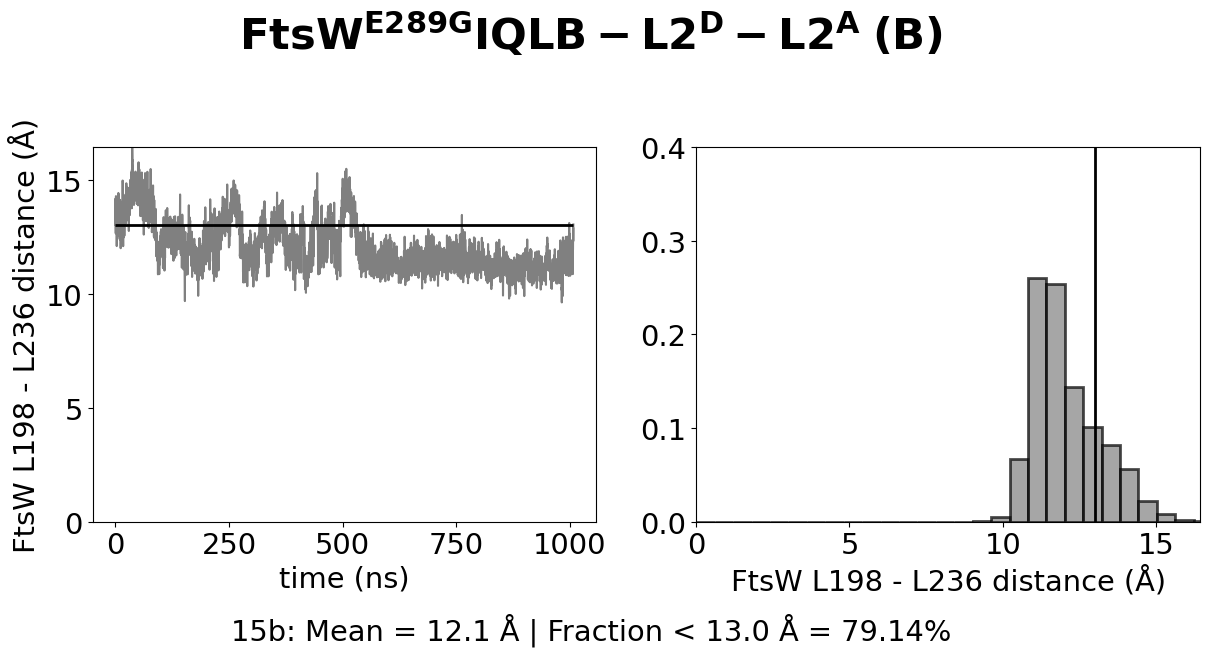

53: Min = 7.8 Å | Frame 16/840 | Time 18.0 ns
53: Mean = 12.1 Å | Fraction < 13.0 Å = 77.62%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_L198_L236_Ca_dist\53_FtsW_L198-L236.png


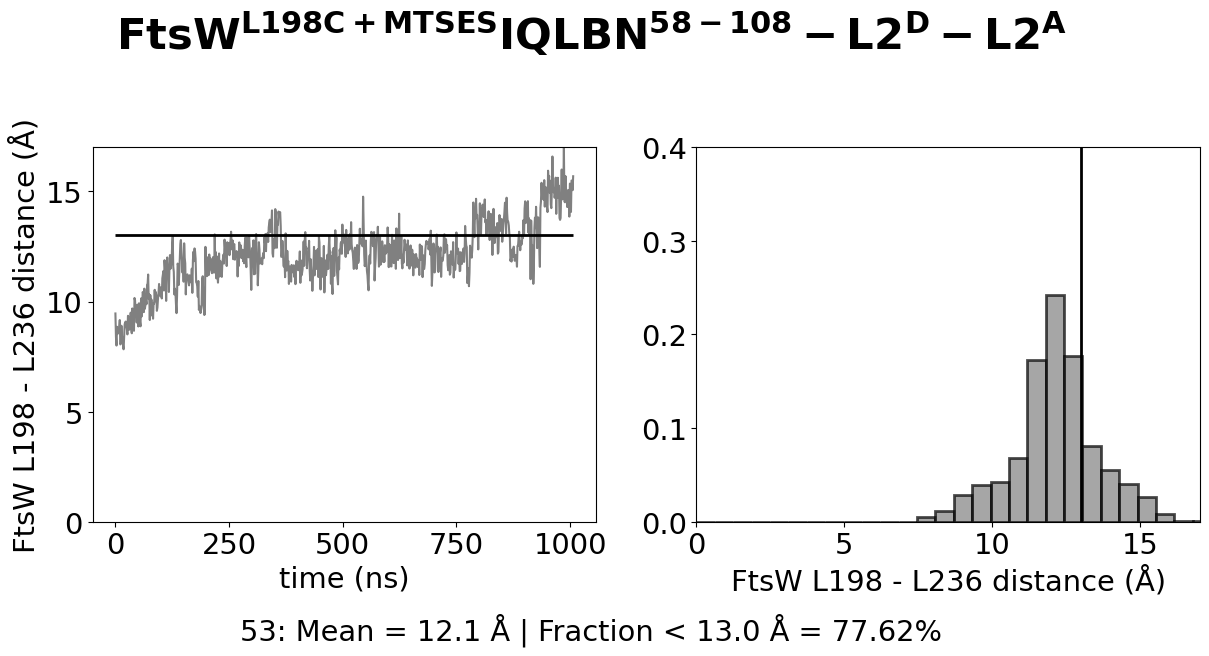

54: Min = 8.9 Å | Frame 486/830 | Time 582.0 ns
54: Mean = 10.3 Å | Fraction < 13.0 Å = 100.00%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_L198_L236_Ca_dist\54_FtsW_L198-L236.png


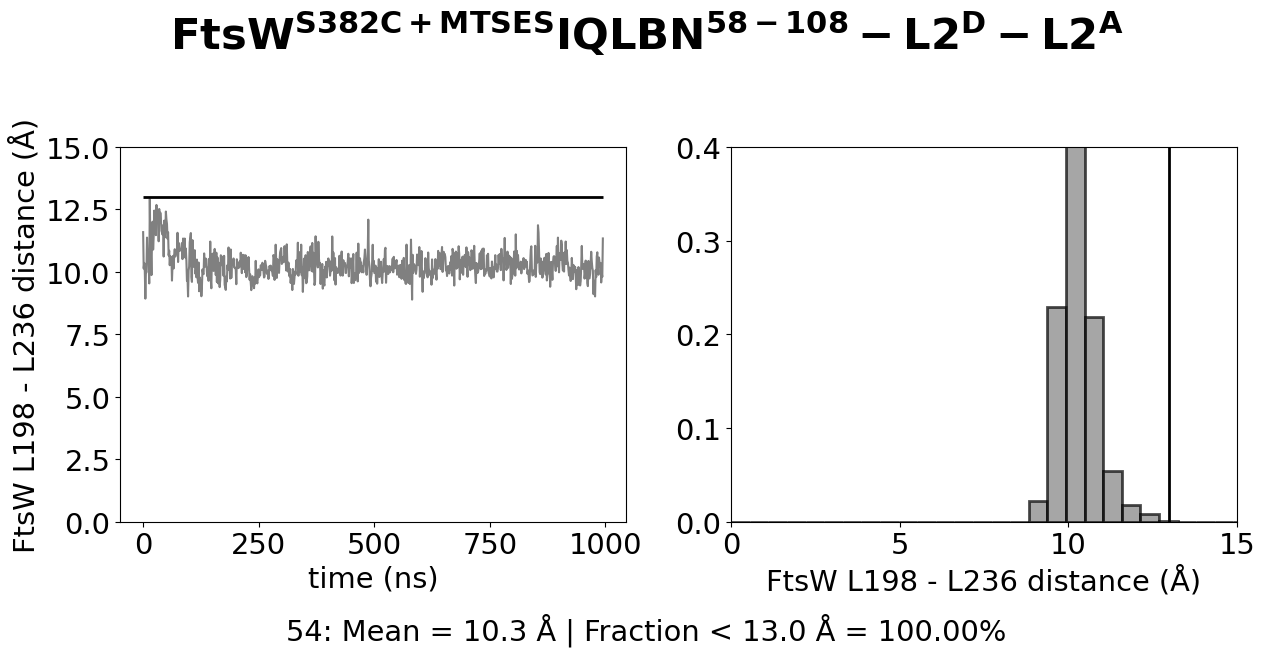

58: Min = 7.4 Å | Frame 822/840 | Time 985.2 ns
58: Mean = 10.2 Å | Fraction < 13.0 Å = 99.76%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_L198_L236_Ca_dist\58_FtsW_L198-L236.png


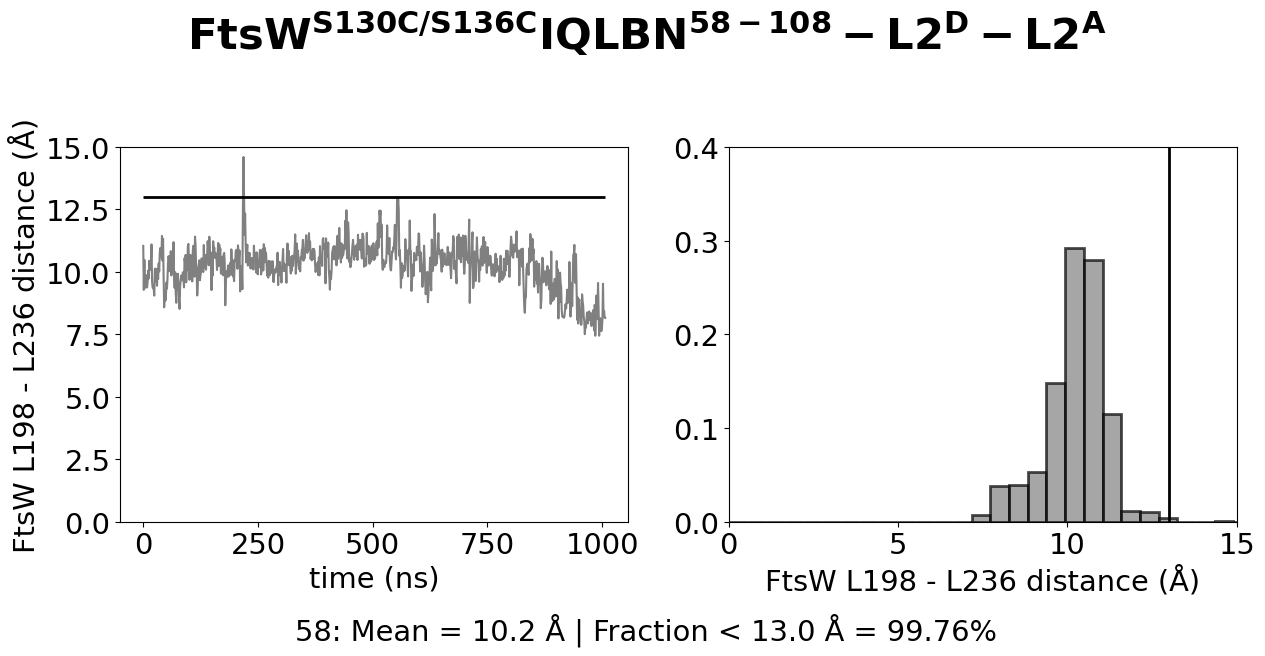

42: Min = 7.2 Å | Frame 2939/3310 | Time 3525.6 ns
42: Mean = 8.2 Å | Fraction < 13.0 Å = 100.00%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_L198_L236_Ca_dist\42_FtsW_L198-L236.png


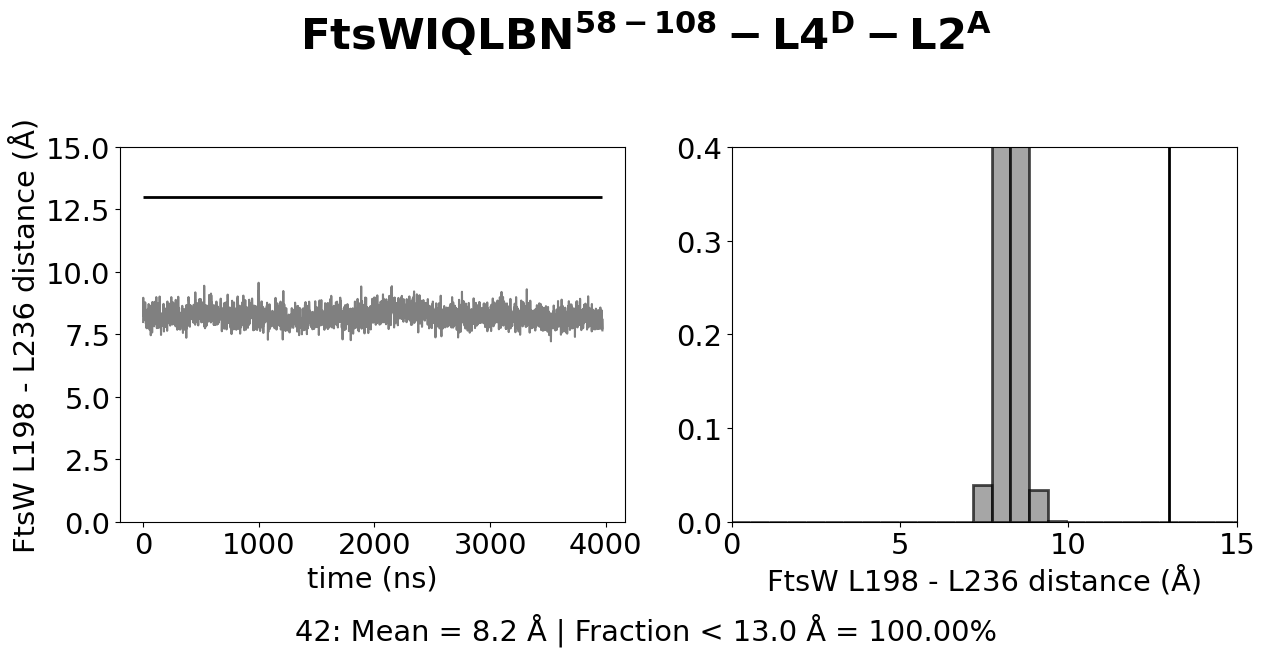

43: Min = 7.1 Å | Frame 2892/3310 | Time 3469.2 ns
43: Mean = 8.2 Å | Fraction < 13.0 Å = 100.00%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_L198_L236_Ca_dist\43_FtsW_L198-L236.png


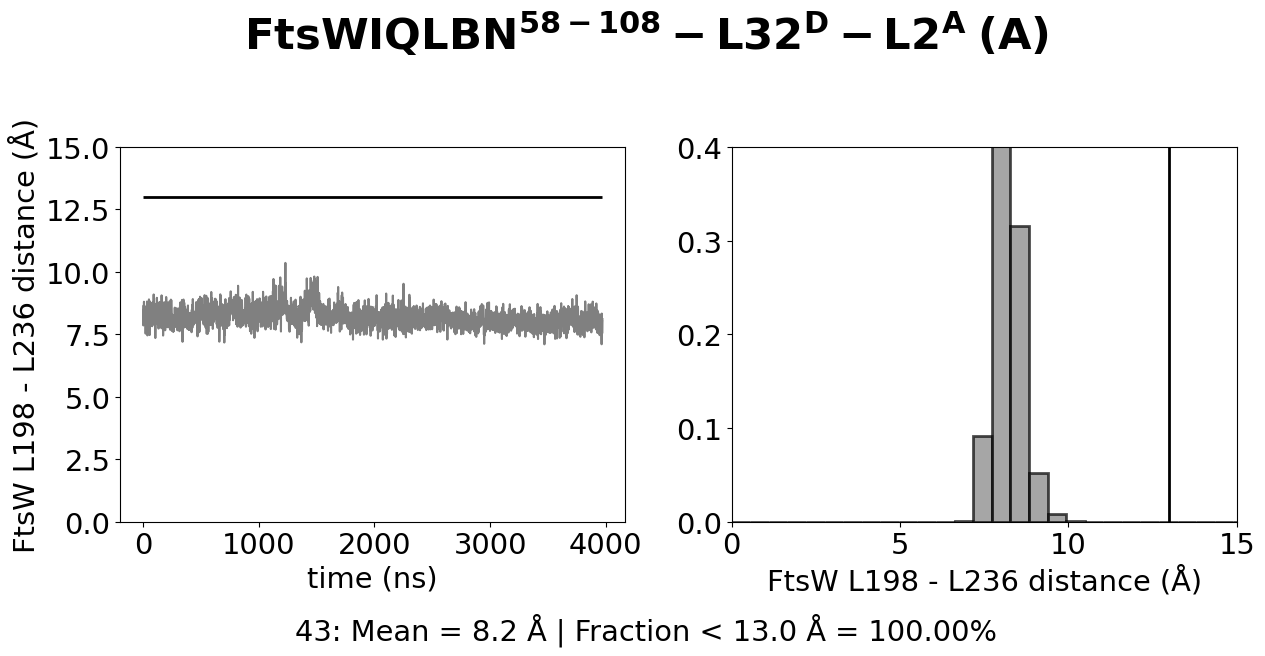

48: Min = 9.8 Å | Frame 16/625 | Time 36.0 ns
48: Mean = 15.3 Å | Fraction < 13.0 Å = 13.44%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_L198_L236_Ca_dist\48_FtsW_L198-L236.png


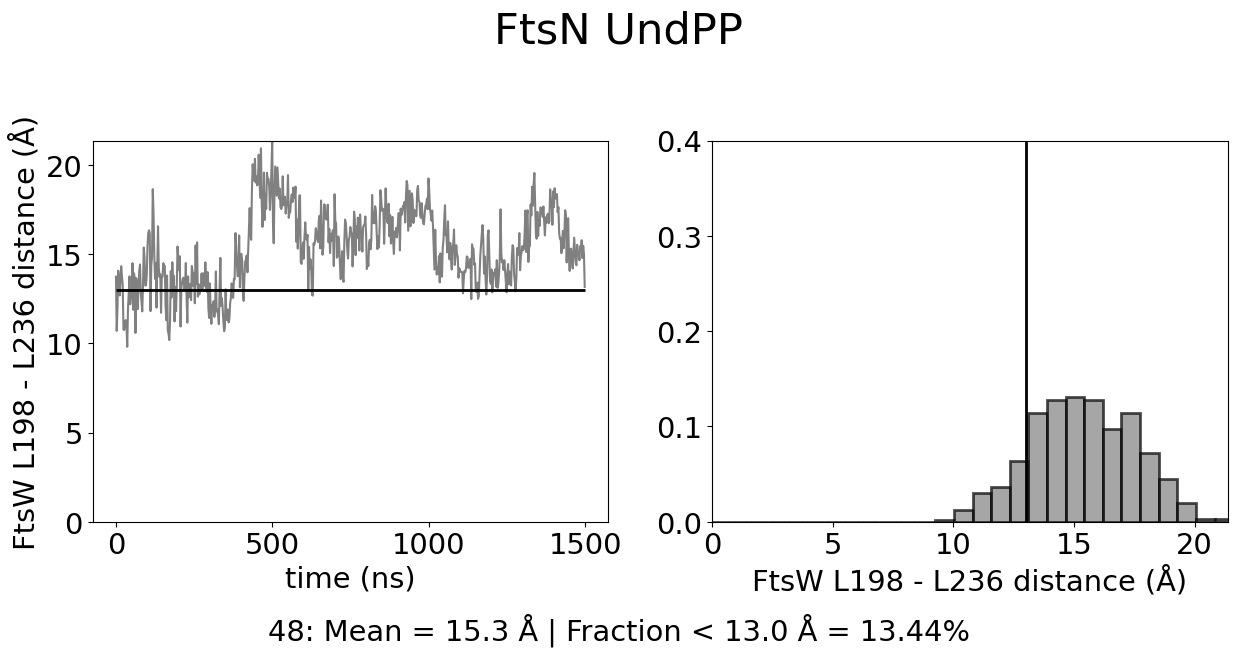

49: Min = 19.6 Å | Frame 213/335 | Time 254.4 ns
49: Mean = 20.9 Å | Fraction < 13.0 Å = 0.00%
Wrote to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_L198_L236_Ca_dist\49_FtsW_L198-L236.png


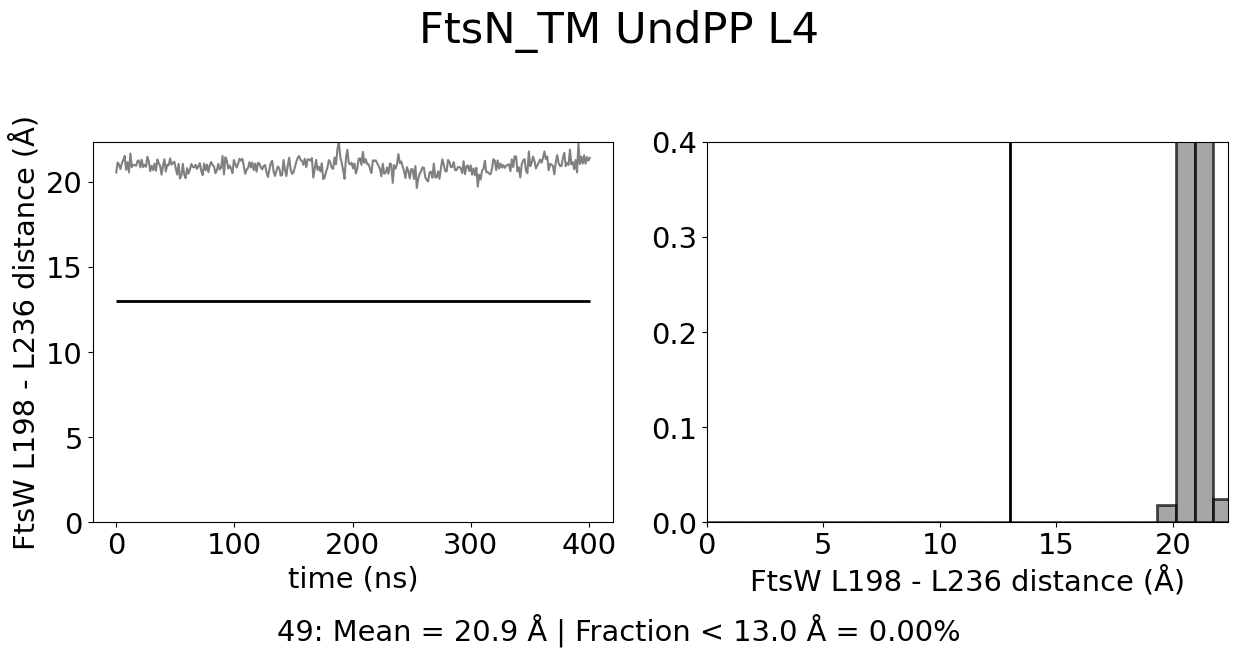

In [7]:
# Plotting (reads CSV cache)

style = cfg.plot_style

if style.var_name_plot is None:
    var_name_plot = cfg.var_name
else:
    var_name_plot = style.var_name_plot

for sim_number, csv_path in data_dict.items():
    sim_number = str(sim_number)

    if sim_number in LABEL_MAP:
        sim_name = LABEL_MAP[sim_number]
    else:
        try:
            m = sim_list.index(sim_number)
            sim_name = label_list[m]
        except ValueError:
            sim_name = sim_number

    plot_dist_time_trace_hist(
        csv_file=csv_path,
        var_name=var_name_plot,
        sim_name=sim_name,
        x_cutoff=cfg.x_cutoff,
        x_lim=(style.x_min_shared, style.x_max_shared) if style.share_lim else None,
        max_hist=style.max_hist,
        split_title=True,
        scale=style.scale,
    )


Common end time (longest sim): 3970.80 ns
Saved combined contact summary to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\FtsW_L198_L236_Ca_dist\paper_revisions_ContactSummary_FtsW_L198-L236.png


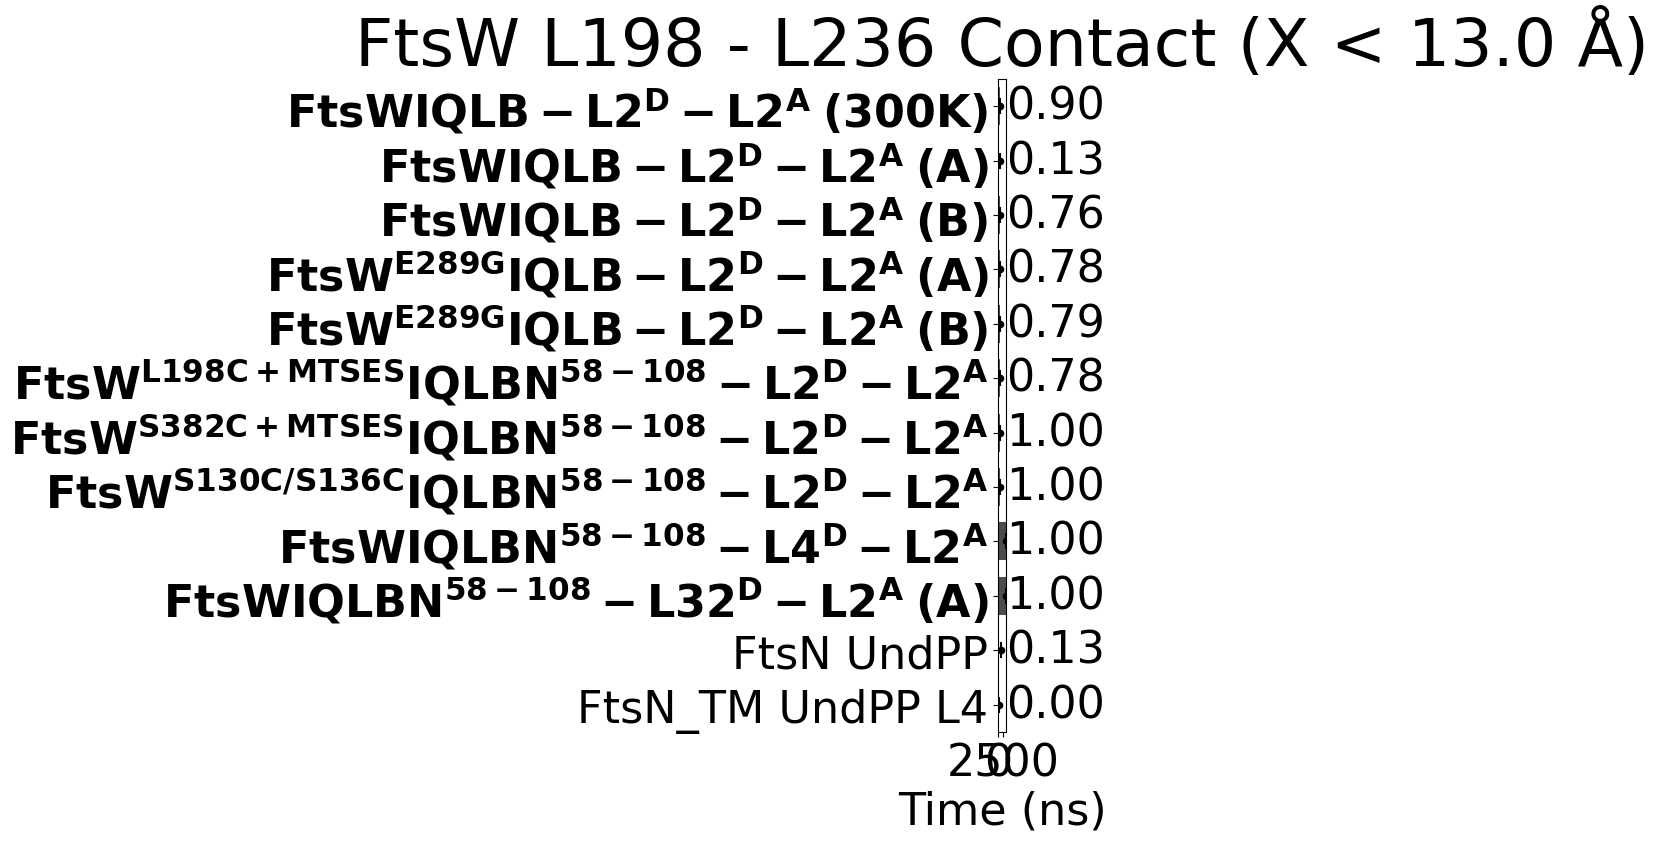

'D:\\Xiao Lab Dropbox\\Lab Members\\Yehya_Nico\\Projects\\MDfolder\\FtsW Manuscript\\FtsW_L198_L236_Ca_dist\\paper_revisions_ContactSummary_FtsW_L198-L236.png'

In [8]:
# Contact summary (curated list preset, per-variable override persisted if changed)

from curated_lists import (
    curated_list_with_optional_override,
    persist_per_variable_override_if_changed,
)
from contact_summary import ContactSummaryStyle, plot_contact_summary

# Use preset selection from the Parameters cell (paper_main vs paper_revisions)
CURATED_DIR = REPO_ROOT / "notebooks" / "curated"

# 1) Default curated list: the sim_list selected *before* trajectory loading
DEFAULT_CURATED = list(sim_list)

# 2) Optional per-variable override file
# If this file exists, it overrides DEFAULT_CURATED.
CURATED_FILE = CURATED_DIR / f"{PRESET_NAME}_{cfg.short_var_name}.txt"

summary_list = curated_list_with_optional_override(DEFAULT_CURATED, CURATED_FILE, required=False)

# If you changed DEFAULT_CURATED in the notebook (or edited summary_list),
# persist that change for this variable only.
written = persist_per_variable_override_if_changed(
    default_sims=DEFAULT_CURATED,
    used_sims=summary_list,
    curated_dir=CURATED_DIR,
    short_var_name=cfg.short_var_name,
    preset_name=PRESET_NAME,
    overwrite=True,
)
if written:
    print(f"Wrote curated override: {written}")

style = ContactSummaryStyle(scale=4.0, long_end=True, below_cutoff=True)

out_png = Path(cfg.out_dir) / f"{PRESET_NAME}_ContactSummary_{cfg.short_var_name}.png"

plot_contact_summary(
    data_dict=data_dict,
    out_png_path=str(out_png),
    var_name=cfg.var_name,
    x_cutoff=float(cfg.x_cutoff),
    summary_list=summary_list,
    sim_list=sim_list,
    label_list=label_list,
    num_to_label=LABEL_MAP,
    style=style,
)
